<a href="https://colab.research.google.com/github/Sherlysukmadira/2311532015_Sherly-Sukmadira-Putri_ImageProcessing/blob/main/Fakenews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA

In [ ]:
! pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00


In [ ]:
! pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=5e3de76d29a96ca7ea8c99534110f9edddcc34e81542d7d18a389cba93d839a7
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
! pip install wordcloud

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re
import contractions
import nltk
import string
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords, words
from langdetect import detect
from langdetect import detect, DetectorFactory
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('words')
nltk.download('stopwords')
nltk.download('punkt')

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# jalankan sekali di Colab
!pip install -q transformers datasets evaluate scikit-learn pandas numpy tensorflow torch sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00


In [ ]:
# Imports umum
import os, random, time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier, StackingClassifier
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("preprocessed_welfake.csv", engine="python", on_bad_lines="skip")

df['label'] = df['label'].map(lambda x: 1 if str(x).lower() in ["fake","1","true","f","fake news","fake_news"] else 0)

print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))
df.head(10)


label
1    571
0    546
Name: count, dtype: int64
label
1    0.511191
0    0.488809
Name: proportion, dtype: float64


,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,en,182,0.0318875024757377,30.0,0.080000,"['law', 'enforcement', 'high', 'alert', 'follo...","['no_comment', 'expect', 'back', 'drama', 'mem...",130.0,5049.0,5179.0,"['law', 'enforcement', 'high', 'alert', 'follo...",LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,en,2,0.0231481481481481,0.0,0.121875,"['unbelievable', 'drama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",137.0,216.0,353.0,"['unbelievable', 'drama', 'attorney', 'general...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,en,154,0.0307116104868913,34.0,0.000000,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","['dozen', 'politically', 'active', 'pastor', '...",105.0,8010.0,8115.0,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","Bobby Jindal, raised Hindu, uses story of Chri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,en,42,0.0641962421711899,70.0,-0.287879,"['satan', 'russia', 'unvelis', 'image', 'terri...","['rs28', 'format', 'missile', 'dub', 'satan', ...",95.0,1916.0,2011.0,"['satan', 'russia', 'unvelis', 'image', 'terri...",SATAN 2: Russia unvelis an image of its terrif...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,en,41,0.0633986928104575,0.0,-0.400000,"['time', 'christian', 'group', 'see', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",78.0,1530.0,1608.0,"['time', 'christian', 'group', 'see', 'amazon'...",About Time! Christian Group Sues Amazon and SP...
5,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1,en,2,0.7901234567901234,0.0,0.000000,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...","['dr', 'ben', 'carson', 'tell', 'story', 'happ...",105.0,81.0,186.0,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...",DR BEN CARSON TARGETED BY THE IRS: “I never ha...
6,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1,en,0,0.0,0.0,-0.500000,"['house', 'inter', 'chair', 'trumprussia', 'fa...",[],79.0,1.0,80.0,"['house', 'inter', 'chair', 'trumprussia', 'fa...",HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...
7,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1,en,33,0.0465601111883252,0.0,0.087500,"['sport', 'bar', 'owner', 'bank', 'nl', 'games...","['owner', 'ring', 'bar', 'locate', 'south', 'w...",116.0,1439.0,1555.0,"['sport', 'bar', 'owner', 'bank', 'nl', 'games...",Sports Bar Owner Bans NFL Games…Will Show Only...
8,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1,en,90,0.0415696707682075,34.0,0.500000,[],"['file', 'sept', 'file', 'photo', 'marker', 'w...",66.0,3007.0,3073.0,"[]['file', 'sept', 'file', 'photo', 'marker', ...",Latest Pipeline Leak Underscores Dangers Of Da...
9,GOP Senator Just Smacked Down The Most Puncha...,The most punchable Alt-Right Nazi on the inter...,1,en,250,0.0559948706988672,121.0,0.172222,"['go', 'senator', 'smack', 'punchable', 'alrig...","['punchable', 'alright', 'nasi', 'internet', '...",80.0,4679.0,4759.0,"['go', 'senator', 'smack', 'punchable', 'alrig...",GOP Senator Just Smacked Down The Most Puncha...


In [ ]:
DATA_PATH = "preprocessed_welfake.csv"   # ganti sesuai nama file
df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
print("Total rows:", len(df))

# pastikan label numeric 0/1
df['label'] = df['label'].map(lambda x: 1 if str(x).lower() in ["fake","1","true","f","fake news","fake_news"] else 0)

# sample 10k fake + 10k real (jika tersedia)
fake = df[df['label']==1]
real = df[df['label']==0]

n_each = 10000
fake_s = fake.sample(n=min(n_each, len(fake)), random_state=42)
real_s = real.sample(n=min(n_each, len(real)), random_state=42)

small_df = pd.concat([fake_s, real_s]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Subset shape:", small_df.shape)
small_df.to_csv("welfake_20k.csv", index=False)


Total rows: 6752
Subset shape: (6752, 15)


In [ ]:
df.dropna(subset=['title'], inplace=True)
df.dropna(subset=['text'], inplace=True)

In [ ]:
import re
def clean_text(s):
    if pd.isna(s): return ""
    s = s.lower()
    s = re.sub(r"http\S+"," ",s)
    s = re.sub(r"\n"," ",s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

small_df['text_clean'] = small_df['text'].astype(str).apply(clean_text)


In [ ]:
train_df, test_df = train_test_split(small_df, test_size=0.2, stratify=small_df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['label'], random_state=42)  # so final: 70/10/20

print(len(train_df), len(val_df), len(test_df))


4725 676 1351


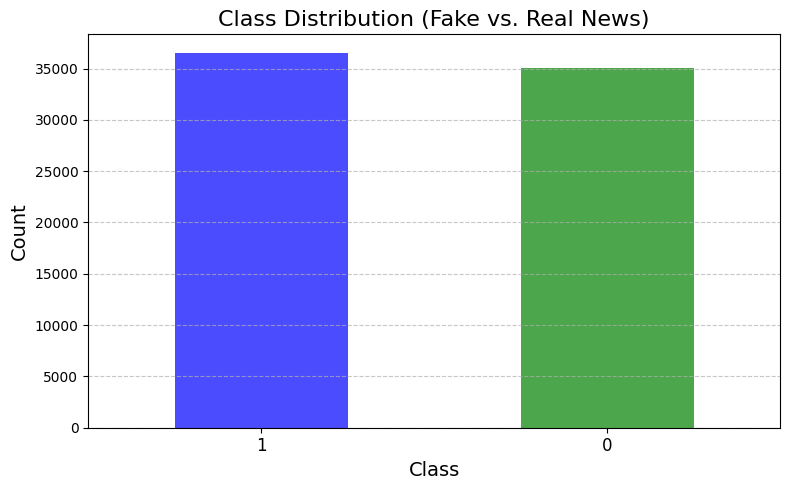

In [ ]:
class_counts = df['label'].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['blue', 'green'], alpha=0.7)
plt.title('Class Distribution (Fake vs. Real News)', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

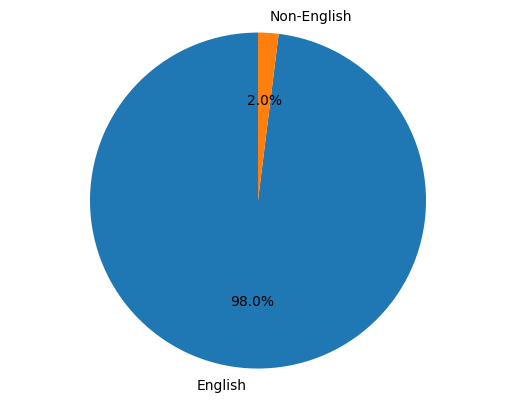

In [ ]:
DetectorFactory.seed = 0

def detect_language(text):
    try:
        return detect(text)
    except:
        return "Error"

df['language'] = df['text'].apply(detect_language)
language_counts = df['language'].value_counts()

english_count = language_counts.get('en', 0)
non_english_count = sum(language_counts) - english_count

labels = 'English', 'Non-English'
sizes = [english_count, non_english_count]

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')

plt.show()


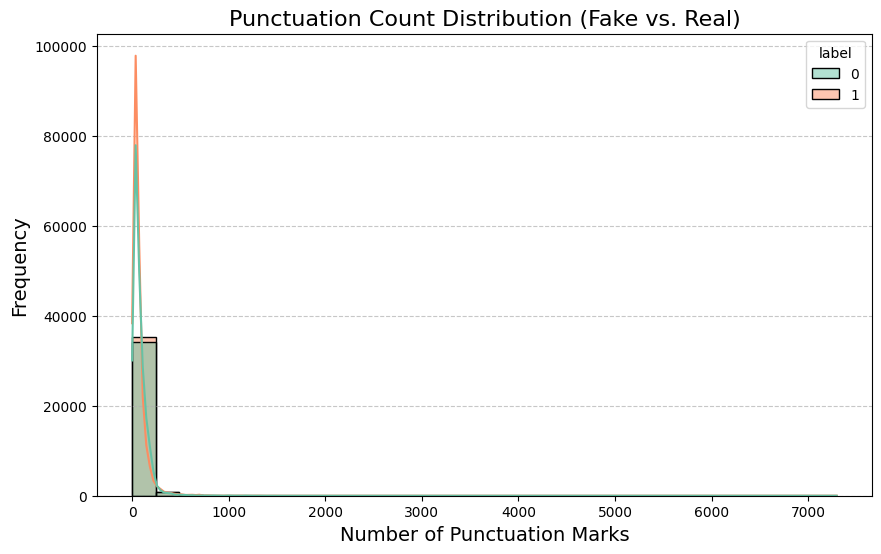

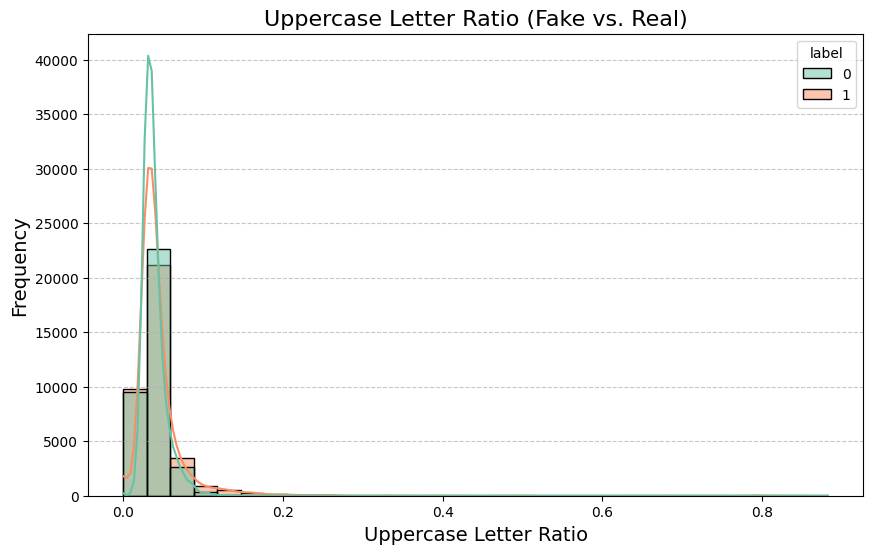

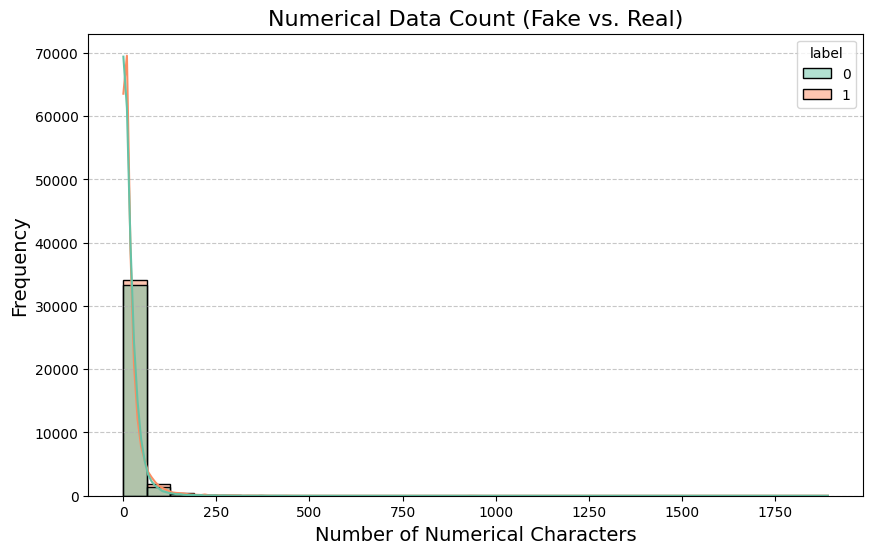

In [ ]:
# Counting punctuations
df['punctuation_count'] = df['text'].apply(lambda x: sum([1 for char in x if char in string.punctuation]))

# Counting uppercase letters
df['uppercase_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

# Counting numerical data
df['numerical_count'] = df['text'].apply(lambda x: sum(1 for char in x if char.isdigit()))

# Plot for punctuatios
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='punctuation_count', hue='label', bins=30, kde=True, palette='Set2')
plt.title('Punctuation Count Distribution (Fake vs. Real)', fontsize=16)
plt.xlabel('Number of Punctuation Marks', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot for uppercase letters
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='uppercase_ratio', hue='label', bins=30, kde=True, palette='Set2')
plt.title('Uppercase Letter Ratio (Fake vs. Real)', fontsize=16)
plt.xlabel('Uppercase Letter Ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot for numerical data
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='numerical_count', hue='label', bins=30, kde=True, palette='Set2')
plt.title('Numerical Data Count (Fake vs. Real)', fontsize=16)
plt.xlabel('Number of Numerical Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

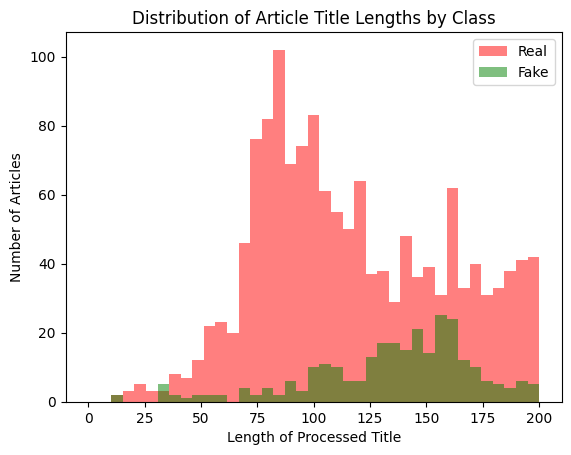

In [ ]:
bins = np.linspace(0, 200, 40)

df['title_len'] = df['title'].apply(len) #length of the title
df['text_len'] = df['text'].apply(len) #length of the text column
df['total_len'] = df['title_len'] + df['text_len'] #total

#bins = np.linspace(0, df['total_len'].max(), 40)

plt.hist(df[df["label"] == 1]["total_len"], bins, alpha=0.5, label="Real", color="red")
plt.hist(df[df["label"] == 0]["total_len"], bins, alpha=0.5, label="Fake", color="green")
plt.legend(loc="upper right")
plt.xlabel('Length of Processed Title')
plt.ylabel('Number of Articles')
plt.title('Distribution of Article Title Lengths by Class')
plt.show()

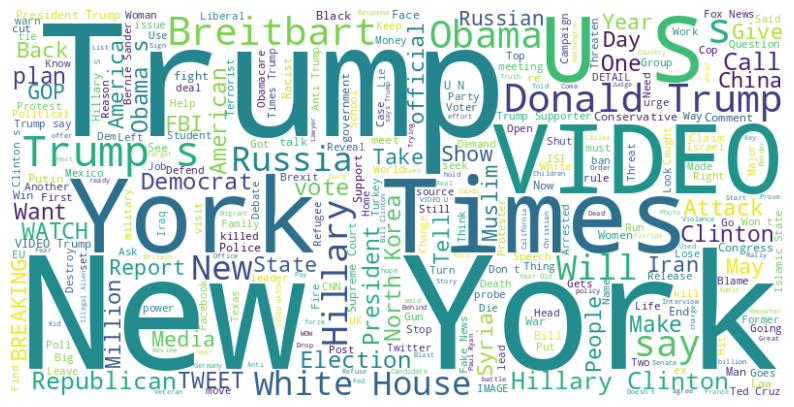

In [ ]:
titles = ' '.join(title for title in df['title'])
wordcloud = WordCloud(
    background_color='white',
    max_words=300,
    width=800,
    height=400,
).generate(titles)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
# Extracting 2 dataframes from df(dataset) based on the label: 0 & 1 which are fake and real news

fake_news = df[df['label'] == 0]
real_news = df[df['label'] == 1]

In [ ]:
real_news

,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,en,182,0.031888,30,0.08,"['law', 'enforcement', 'high', 'alert', 'follo...","['no_comment', 'expect', 'back', 'drama', 'mem...",130,5049,5179,"['law', 'enforcement', 'high', 'alert', 'follo...",LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,en,2,0.023148,0,0.121875,"['unbelievable', 'drama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",137,216,353,"['unbelievable', 'drama', 'attorney', 'general...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,en,42,0.064196,70,-0.2878787878787879,"['satan', 'russia', 'unvelis', 'image', 'terri...","['rs28', 'format', 'missile', 'dub', 'satan', ...",95,1916,2011,"['satan', 'russia', 'unvelis', 'image', 'terri...",SATAN 2: Russia unvelis an image of its terrif...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,en,41,0.063399,0,-0.4,"['time', 'christian', 'group', 'see', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",78,1530,1608,"['time', 'christian', 'group', 'see', 'amazon'...",About Time! Christian Group Sues Amazon and SP...
5,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1,en,2,0.790123,0,0.0,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...","['dr', 'ben', 'carson', 'tell', 'story', 'happ...",105,81,186,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...",DR BEN CARSON TARGETED BY THE IRS: “I never ha...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71611,WOW! JILL STEIN’S ‘FIRESIDE CHAT’ Exposes Her ...,,1,en,0,0.000000,0,0.125,"['now', 'will', 'steins', 'fireside', 'chat', ...",[],73,1,74,"['now', 'will', 'steins', 'fireside', 'chat', ...",WOW! JILL STEIN’S ‘FIRESIDE CHAT’ Exposes Her ...
71613,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,en,24,0.041229,0,0.0,"['wikileaks', 'email', 'show', 'clinton', 'fou...","['email', 'release', 'wikileaks', 'sunday', 'a...",104,1237,1341,"['wikileaks', 'email', 'show', 'clinton', 'fou...",WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...
71614,JUDGE JEANINE SOUNDS FREE SPEECH ALARM: “They ...,Judge Jeanine lets it rip! She s concerned wit...,1,en,150,0.051282,62,0.2,"['judge', 'mean', 'sound', 'free', 'speech', '...","['judge', 'mean', 'let', 'u', 'rip', 'concerne...",105,5226,5331,"['judge', 'mean', 'sound', 'free', 'speech', '...",JUDGE JEANINE SOUNDS FREE SPEECH ALARM: “They ...
71616,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,en,51,0.033021,17,0.0,"['watch', 'giuliani', 'demand', 'democrat', 'a...","['know', 'fantasyland', 'republican', 'never_q...",79,3634,3713,"['watch', 'giuliani', 'demand', 'democrat', 'a...",WATCH: Giuliani Demands That Democrats Apolog...


visualisasi fake

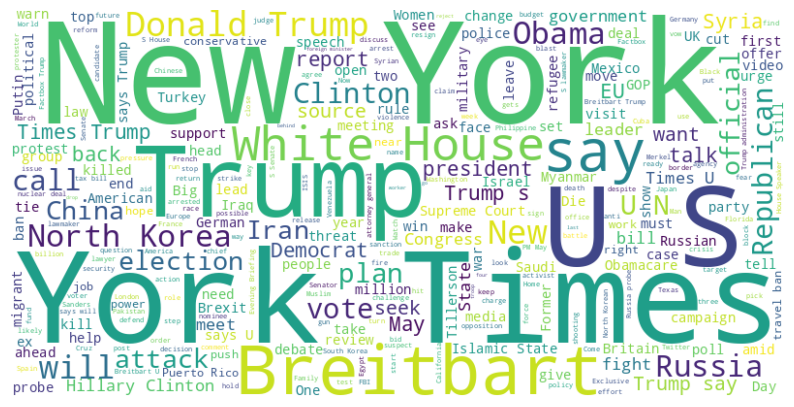

In [ ]:
fake_texts = ' '.join(text for text in fake_news['title'])
wordcloud = WordCloud(
    background_color='white',
    max_words=300,
    width=800,
    height=400,
).generate(fake_texts)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_n=20, stop_words='english'):
    # Pastikan corpus bukan Series kosong
    if getattr(corpus, "shape", None) is not None and len(corpus) == 0:
        return []
    # Convert ke list of str dan dropna
    corpus_list = [str(x) for x in corpus.dropna().tolist()]

    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words=stop_words)
    X = vectorizer.fit_transform(corpus_list)

    # Compatibility: use get_feature_names_out if available
    try:
        ngrams = vectorizer.get_feature_names_out()
    except AttributeError:
        # older sklearn
        ngrams = vectorizer.get_feature_names()

    counts = X.toarray().sum(axis=0)
    ngram_freq = dict(zip(ngrams, counts))
    sorted_ngrams = sorted(ngram_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return sorted_ngrams

# Contoh panggilan (sesuaikan label jika pada datasetmu beda)
fake_bigrams = get_top_ngrams(df[df['label'] == 1]['title'], n=2, top_n=20)
real_bigrams = get_top_ngrams(df[df['label'] == 0]['title'], n=2, top_n=20)

fake_trigrams = get_top_ngrams(df[df['label'] == 1]['title'], n=3, top_n=20)
real_trigrams = get_top_ngrams(df[df['label'] == 0]['title'], n=3, top_n=20)

def print_ngrams(ngram_list, heading):
    print(heading)
    if not ngram_list:
        print("  (no ngrams found)")
    for gram, freq in ngram_list:
        print(f"  {gram}: {freq}")
    print()

print_ngrams(fake_bigrams, "Top 20 Bigrams in Fake News Titles:")
print_ngrams(real_bigrams, "Top 20 Bigrams in Real News Titles:")
print_ngrams(fake_trigrams, "Top 20 Trigrams in Fake News Titles:")
print_ngrams(real_trigrams, "Top 20 Trigrams in Real News Titles:")


Top 20 Bigrams in Fake News Titles:
  donald trump: 1144
  hillary clinton: 891
  president trump: 517
  white house: 403
  fox news: 334
  anti trump: 308
  trump video: 303
  bernie sanders: 268
  trump supporter: 247
  trump supporters: 240
  ted cruz: 232
  fake news: 227
  trump just: 219
  year old: 208
  boiler room: 205
  lives matter: 199
  supreme court: 196
  president obama: 193
  black lives: 191
  yr old: 178

Top 20 Bigrams in Real News Titles:
  new york: 6480
  york times: 6270
  white house: 980
  donald trump: 878
  north korea: 769
  trump says: 399
  hillary clinton: 376
  supreme court: 343
  islamic state: 333
  briefing new: 203
  puerto rico: 185
  travel ban: 183
  south korea: 176
  trump administration: 176
  says trump: 163
  evening briefing: 148
  nuclear deal: 142
  factbox trump: 141
  house speaker: 129
  trump new: 126

Top 20 Trigrams in Fake News Titles:
  black lives matter: 184
  boiler room ep: 138
  america finest news: 109
  finest news source:

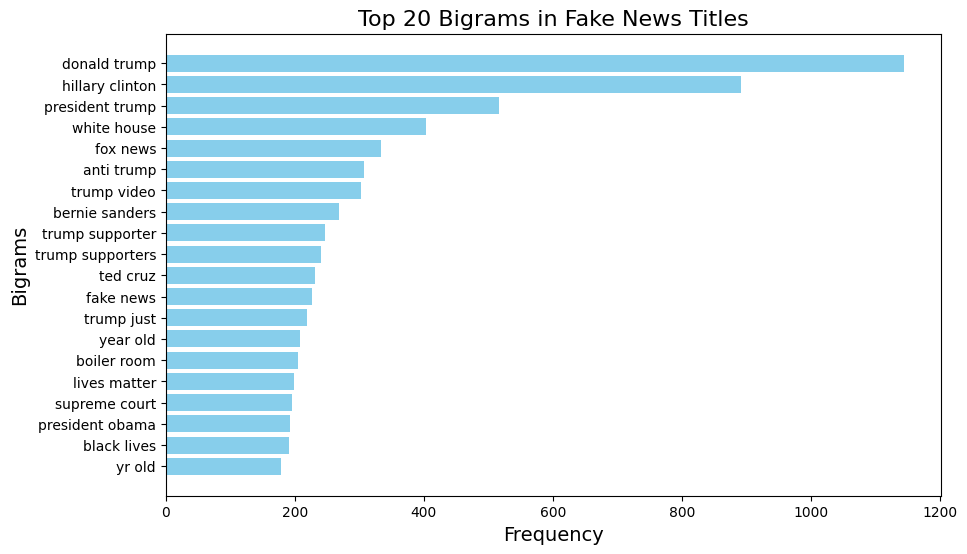

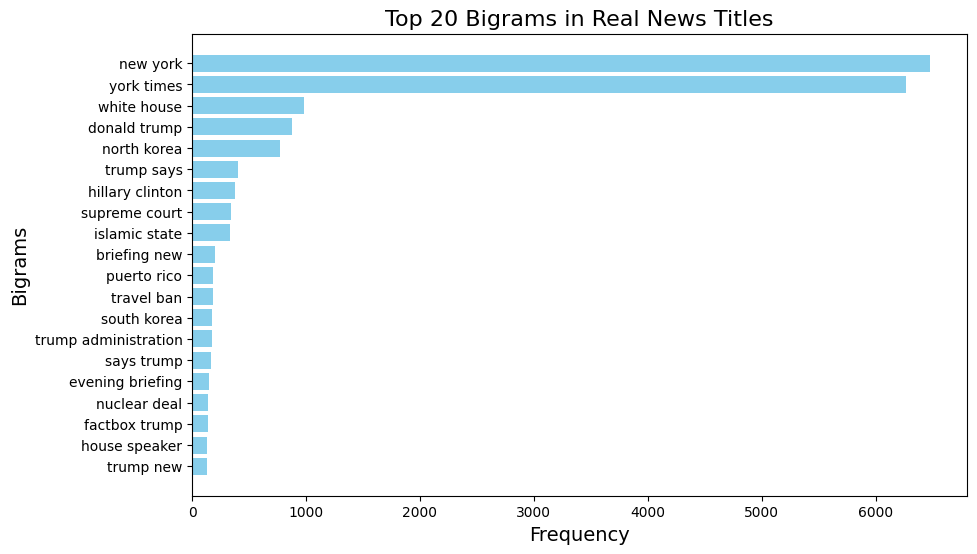

In [ ]:
# Visualize n-grams
def plot_ngrams(ngrams, title):
    labels, values = zip(*ngrams)
    plt.figure(figsize=(10, 6))
    plt.barh(labels, values, color='skyblue')
    plt.title(title, fontsize=16)
    plt.xlabel('Frequency', fontsize=14)
    plt.ylabel('Bigrams', fontsize=14)
    plt.gca().invert_yaxis()
    plt.show()

plot_ngrams(fake_bigrams, 'Top 20 Bigrams in Fake News Titles')
plot_ngrams(real_bigrams[:20], 'Top 20 Bigrams in Real News Titles')

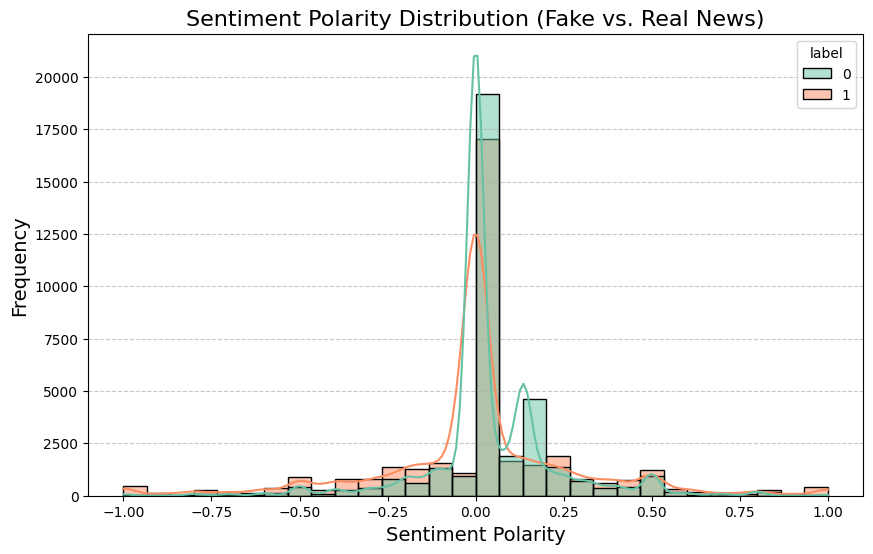

In [ ]:
# Sentiment polarity
df['sentiment_polarity'] = df['title'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='sentiment_polarity', hue='label', bins=30, kde=True, palette='Set2')
plt.title('Sentiment Polarity Distribution (Fake vs. Real News)', fontsize=16)
plt.xlabel('Sentiment Polarity', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
df

,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,en,182,0.031888,30,0.080000,"['law', 'enforcement', 'high', 'alert', 'follo...","['no_comment', 'expect', 'back', 'drama', 'mem...",130,5049,5179,"['law', 'enforcement', 'high', 'alert', 'follo...",LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,en,2,0.023148,0,0.121875,"['unbelievable', 'drama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",137,216,353,"['unbelievable', 'drama', 'attorney', 'general...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,en,154,0.030712,34,0.000000,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","['dozen', 'politically', 'active', 'pastor', '...",105,8010,8115,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","Bobby Jindal, raised Hindu, uses story of Chri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,en,42,0.064196,70,-0.287879,"['satan', 'russia', 'unvelis', 'image', 'terri...","['rs28', 'format', 'missile', 'dub', 'satan', ...",95,1916,2011,"['satan', 'russia', 'unvelis', 'image', 'terri...",SATAN 2: Russia unvelis an image of its terrif...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,en,41,0.063399,0,-0.400000,"['time', 'christian', 'group', 'see', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",78,1530,1608,"['time', 'christian', 'group', 'see', 'amazon'...",About Time! Christian Group Sues Amazon and SP...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71615,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,en,105,0.038012,35,0.000000,"['russian', 'steal', 'research', 'tramp', 'hac...","['washington', 'renter', 'hawker', 'believe', ...",65,4788,4853,"['russian', 'steal', 'research', 'tramp', 'hac...",Russians steal research on Trump in hack of U....
71616,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,en,51,0.033021,17,0.000000,"['watch', 'giuliani', 'demand', 'democrat', 'a...","['know', 'fantasyland', 'republican', 'never_q...",79,3634,3713,"['watch', 'giuliani', 'demand', 'democrat', 'a...",WATCH: Giuliani Demands That Democrats Apolog...
71617,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,en,85,0.036662,10,0.000000,"['emigrant', 'refuse', 'leave', 'train', 'refu...","['emigrant', 'refuse', 'leave', 'train', 'refu...",57,2864,2921,"['emigrant', 'refuse', 'leave', 'train', 'refu...",Migrants Refuse To Leave Train At Refugee Camp...
71618,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0,en,73,0.037048,8,0.000000,"['tramp', 'tissue', 'give', 'unpopular', 'mexi...","['mexico', 'city', 'renter', 'donald', 'troop'...",67,3374,3441,"['tramp', 'tissue', 'give', 'unpopular', 'mexi...",Trump tussle gives unpopular Mexican leader mu...


4. TF-IDF + Classicalmodels (fast baseline)

In [ ]:
X_train = train_df['text_clean'].values
y_train = train_df['label'].values
X_val = val_df['text_clean'].values
y_val = val_df['label'].values
X_test = test_df['text_clean'].values
y_test = test_df['label'].values

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

# Pipeline contoh: Logistic Regression
pipe_lr = Pipeline([('tfidf', tfidf), ('clf', LogisticRegression(max_iter=1000))])
pipe_lr.fit(X_train, y_train)
print("LR val f1:", f1_score(y_val, pipe_lr.predict(X_val)))

pipe_nb = Pipeline([('tfidf', tfidf), ('clf', MultinomialNB())])
pipe_nb.fit(X_train, y_train)
print("NB val f1:", f1_score(y_val, pipe_nb.predict(X_val)))

pipe_svc = Pipeline([('tfidf', tfidf), ('clf', LinearSVC(max_iter=10000))])
pipe_svc.fit(X_train, y_train)
print("SVC val f1:", f1_score(y_val, pipe_svc.predict(X_val)))

# Save models if mau
import joblib
joblib.dump(pipe_lr, "pipe_lr.joblib")
joblib.dump(pipe_nb, "pipe_nb.joblib")
joblib.dump(pipe_svc, "pipe_svc.joblib")


LR val f1: 0.883008356545961
NB val f1: 0.8544474393530997
SVC val f1: 0.9090909090909091


['pipe_svc.joblib']

In [ ]:
!ls /content


drive		pipe_nb.joblib	 preprocessed_welfake.csv  welfake_20k.csv
pipe_lr.joblib	pipe_svc.joblib  sample_data


BERT

In [ ]:
df.columns


Index(['title', 'text', 'label', 'language', 'punctuation_count',
       'uppercase_ratio', 'numerical_count', 'sentiment_polarity',
       'processed_title', 'processed_text', 'title_len', 'text_len',
       'total_len', 'combined_processed_text', 'combined_text_title'],
      dtype='object')

In [ ]:
# Pastikan semua data string
for df in [train_df, val_df, test_df]:
    df['text_clean'] = df['text_clean'].fillna("").astype(str)

# Buat Hugging Face Dataset
hf_train = Dataset.from_pandas(
    train_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)
hf_val = Dataset.from_pandas(
    val_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)
hf_test = Dataset.from_pandas(
    test_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)

# Tokenisasi
hf_train = hf_train.map(tok_func, batched=True, remove_columns=['text'])
hf_val = hf_val.map(tok_func, batched=True, remove_columns=['text'])
hf_test = hf_test.map(tok_func, batched=True, remove_columns=['text'])


NameError: name 'tok_func' is not defined

In [ ]:
# ============================================
# 1. IMPORT
# ============================================
import numpy as np
import pandas as pd
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# ============================================
# 2. CONFIG
# ============================================
MODEL_NAME = "distilbert-base-uncased"    # model ringan
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 1

# ============================================
# 3. PASTIKAN SEMUA TEKS VALID STRING
# ============================================
for df in [train_df, val_df, test_df]:
    df['text_clean'] = df['text_clean'].fillna("").astype(str)

# ============================================
# 4. HUGGINGFACE DATASET
# ============================================
hf_train = Dataset.from_pandas(
    train_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)
hf_val = Dataset.from_pandas(
    val_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)
hf_test = Dataset.from_pandas(
    test_df[['text_clean','label']].rename(columns={'text_clean':'text'})
)

# ============================================
# 5. TOKENIZER
# ============================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok_func(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=False,
        max_length=MAX_LEN
    )

hf_train = hf_train.map(tok_func, batched=True, remove_columns=['text'])
hf_val = hf_val.map(tok_func, batched=True, remove_columns=['text'])
hf_test = hf_test.map(tok_func, batched=True, remove_columns=['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ============================================
# 6. MODEL
# ============================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ============================================
# 7. TRAINING ARGS
# ============================================
training_args = TrainingArguments(
    output_dir="distilbert_model",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

# ============================================
# 8. METRICS
# ============================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# ============================================
# 9. TRAINER
# ============================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ============================================
# 10. TRAINING
# ============================================
trainer.train()

# ============================================
# 11. EVALUATION
# ============================================
print("Evaluating on test set...")
res = trainer.evaluate(eval_dataset=hf_test)
print(res)

# ============================================
# 12. SAVE MODEL
# ============================================
trainer.save_model("distilbert_model_saved")
tokenizer.save_pretrained("distilbert_model_saved")
print("Model saved successfully!")


Map:   0%|          | 0/14000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3368218169.py:102: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in co

...

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.170500,0.145101,0.943000,0.942482


Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.17425285279750824, 'eval_accuracy': 0.932, 'eval_f1': 0.9319319319319319, 'eval_runtime': 756.941, 'eval_samples_per_second': 5.284, 'eval_steps_per_second': 0.33, 'epoch': 1.0}
Model saved successfully!


In [ ]:
# ====== PERBAIKAN & SCRIPT EVALUASI LENGKAP ======
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from statsmodels.stats.contingency_tables import mcnemar
from joblib import load
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---------- 0. cek test_df
# pastikan kolom text_clean dan label ada
assert 'text_clean' in test_df.columns, "test_df harus punya kolom 'text_clean'"
assert 'label' in test_df.columns, "test_df harus punya kolom 'label'"

# ---------- 1. load SVC TF-IDF model
svc_model = load("pipe_svc.joblib")  # ganti path jika perlu

# ---------- 2. device dan model BERT
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Jika kamu sudah punya model & tokenizer di memory (variabel model, tokenizer), gunakan itu.
# Kalau tidak, load dari saved dir:
# tokenizer = AutoTokenizer.from_pretrained("distilbert_model_saved")
# model = AutoModelForSequenceClassification.from_pretrained("distilbert_model_saved")
# Pastikan path sesuai
try:
    tokenizer  # lihat apakah tokenizer sudah ada
    model
except NameError:
    tokenizer = AutoTokenizer.from_pretrained("distilbert_model_saved")
    model = AutoModelForSequenceClassification.from_pretrained("distilbert_model_saved")

model.to(device)
model.eval()

# ---------- 3. BERT Dataset & DataLoader
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }
        return item

# Pastikan label numeric
test_df['label'] = test_df['label'].astype(int)

test_dataset = BERTDataset(
    test_df['text_clean'].tolist(),
    test_df['label'].tolist(),
    tokenizer,
    max_len=128
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ---------- 4. PREDIKSI BERT
bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        # pindahkan ke device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        bert_preds.extend(preds.cpu().numpy())

bert_preds = np.array(bert_preds)
print("BERT predictions done. total:", len(bert_preds))

# ---------- 5. PREDIKSI SVC
svc_preds = svc_model.predict(test_df['text_clean'].values)
svc_preds = np.array(svc_preds)
print("SVC predictions done. total:", len(svc_preds))

# ---------- 6. METRIK
y_true = test_df['label'].values

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

metrics_bert = compute_metrics(y_true, bert_preds)
metrics_svc = compute_metrics(y_true, svc_preds)

comparison_df = pd.DataFrame({
    "Model": ["SVC TF-IDF", "BERT"],
    "Accuracy": [metrics_svc['accuracy'], metrics_bert['accuracy']],
    "Precision": [metrics_svc['precision'], metrics_bert['precision']],
    "Recall": [metrics_svc['recall'], metrics_bert['recall']],
    "F1-score": [metrics_svc['f1'], metrics_bert['f1']]
})

# ---------- 7. MCNEMAR
correct_svc = (svc_preds == y_true)
correct_bert = (bert_preds == y_true)

b01 = np.sum((correct_svc == 0) & (correct_bert == 1))  # SVC salah, BERT benar
b10 = np.sum((correct_svc == 1) & (correct_bert == 0))  # SVC benar, BERT salah

table = [[0, b01],
         [b10, 0]]

# jika sangat kecil jumlah b01+b10, gunakan exact=True; statsmodels mcnemar membutuhkan table 2x2 non-trivial
try:
    mcnemar_result = mcnemar(table, exact=True)
    pval = mcnemar_result.pvalue
except Exception as e:
    # fallback ke approximate
    mcnemar_result = mcnemar(table, exact=False, correction=True)
    pval = mcnemar_result.pvalue

# ---------- 8. CONFUSION MATRICES & REPORT
cm_svc = confusion_matrix(y_true, svc_preds)
cm_bert = confusion_matrix(y_true, bert_preds)

print("\n=== PERBANDINGAN KINERJA MODEL ===")
print(comparison_df.to_string(index=False))

print("\n=== CONFUSION MATRIX SVC ===")
print(cm_svc)
print("\nSVC classification report:")
print(classification_report(y_true, svc_preds, zero_division=0))

print("\n=== CONFUSION MATRIX BERT ===")
print(cm_bert)
print("\nBERT classification report:")
print(classification_report(y_true, bert_preds, zero_division=0))

print("\n=== MCNEMAR TEST ===")
print("b01 (SVC wrong, BERT right) =", b01)
print("b10 (SVC right, BERT wrong) =", b10)
print("p-value =", pval)
if pval < 0.05:
    print("Kesimpulan: PERBEDAAN SIGNIFIKAN (p < 0.05)")
else:
    print("Kesimpulan: Perbedaan TIDAK SIGNIFIKAN (p >= 0.05)")


Using device: cpu
BERT predictions done. total: 4000
SVC predictions done. total: 4000

=== PERBANDINGAN KINERJA MODEL ===
     Model  Accuracy  Precision  Recall  F1-score
SVC TF-IDF    0.9485   0.939275   0.959  0.949035
      BERT    0.9320   0.932866   0.931  0.931932

=== CONFUSION MATRIX SVC ===
[[1876  124]
 [  82 1918]]

SVC classification report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2000
           1       0.94      0.96      0.95      2000

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000


=== CONFUSION MATRIX BERT ===
[[1866  134]
 [ 138 1862]]

BERT classification report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2000
           1       0.93      0.93      0.93      2000

    accuracy                           0.93      4000
   macro a

Evaluasi train model svm

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# DATA (sesuai dataset kamu)
X_train = train_df['text_clean']
y_train = train_df['label']

X_test = test_df['text_clean']
y_test = test_df['label']

# TF-IDF + SVM Pipeline
pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ('svc', LinearSVC())
])

pipe_svc.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                ('svc', LinearSVC())])

In [ ]:
#prediksi train dan test
y_pred_train_svc = pipe_svc.predict(X_train)
y_pred_test_svc  = pipe_svc.predict(X_test)


In [ ]:
svc_train_acc = accuracy_score(y_train, y_pred_train_svc)
svc_test_acc  = accuracy_score(y_test, y_pred_test_svc)

svc_train_f1 = f1_score(y_train, y_pred_train_svc)
svc_test_f1  = f1_score(y_test, y_pred_test_svc)

print("SVC Train F1:", svc_train_f1)
print("SVC Test F1:", svc_test_f1)


SVC Train F1: 0.9970733100149903
SVC Test F1: 0.9490351311232064


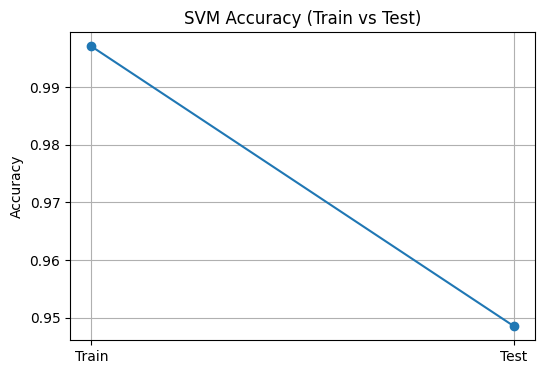

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(['Train','Test'], [svc_train_acc, svc_test_acc], marker='o')
plt.title("SVM Accuracy (Train vs Test)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [ ]:
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
val_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]


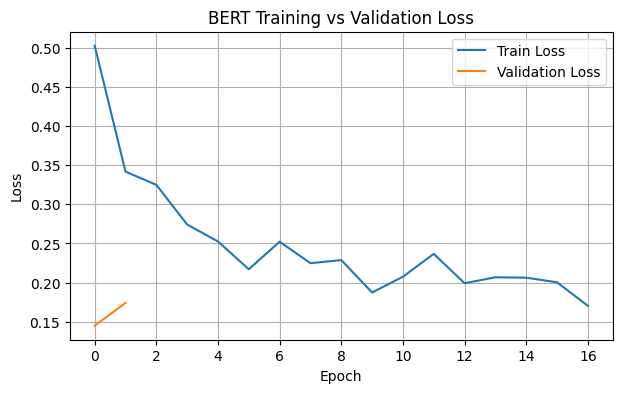

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title("BERT Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


Evaluasi BERT

In [ ]:
bert_test_eval = trainer.evaluate(eval_dataset=hf_test)
bert_test_eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.17425285279750824,
 'eval_accuracy': 0.932,
 'eval_f1': 0.9319319319319319,
 'eval_runtime': 1042.1573,
 'eval_samples_per_second': 3.838,
 'eval_steps_per_second': 0.24,
 'epoch': 1.0}

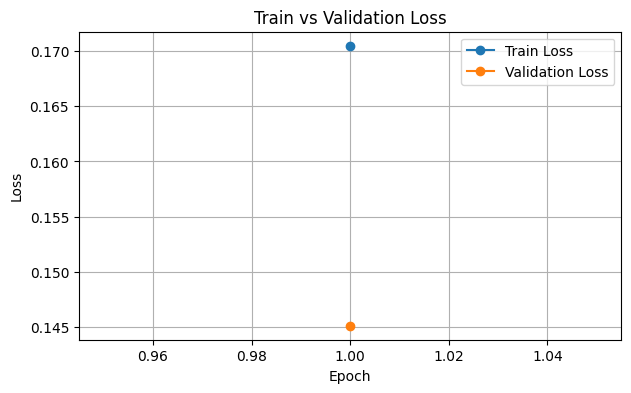

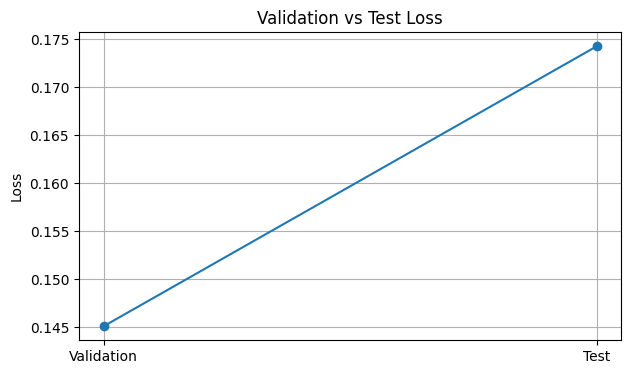

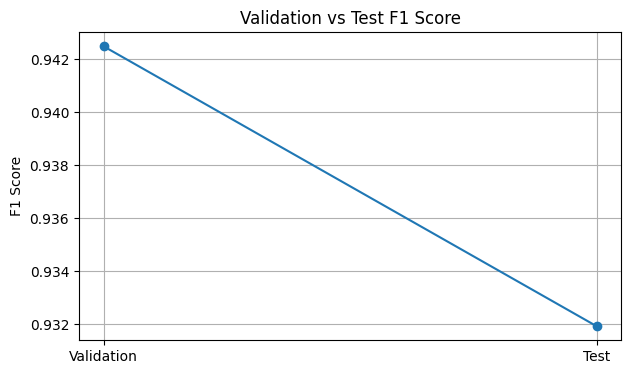

In [ ]:
import matplotlib.pyplot as plt

# ================================
# DATA DARI TRAINING SEBELUMNYA
# ================================
epochs = [1]

train_loss = [0.170500]
val_loss = [0.145101]
test_loss = [0.17425285279750824]

val_accuracy = [0.943000]
val_f1 = [0.942482]

test_accuracy = [0.932]
test_f1 = [0.9319319319319319]

# ================================
# GRAFIK 1: TRAIN VS VAL LOSS
# ================================
plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss, marker='o', label="Train Loss")
plt.plot(epochs, val_loss, marker='o', label="Validation Loss")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ================================
# GRAFIK 2: VAL VS TEST LOSS
# ================================
plt.figure(figsize=(7,4))
plt.plot(["Validation","Test"], [val_loss[0], test_loss[0]], marker="o")
plt.title("Validation vs Test Loss")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ================================
# GRAFIK 3: VAL VS TEST F1
# ================================
plt.figure(figsize=(7,4))
plt.plot(["Validation","Test"], [val_f1[0], test_f1[0]], marker="o")
plt.title("Validation vs Test F1 Score")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()
